In [73]:
#install the pip with libraries and -q for quite mode
!pip install nltk scikit-learn numpy pandas -q

In [74]:
#appload the data set csv file in the folder
#import the libraries Dependencies
import pandas as pd   #to read the csv file
import numpy as np    #to read the numpy file
import matplotlib.pyplot as plt   #to show the data in graph and plot
from sklearn.feature_extraction.text import TfidfVectorizer  #to vectorize the data convert the content
from sklearn.metrics.pairwise import cosine_similarity    #to calcuate the cosine in similarity
import re  #to clean the data like removing the specific characters regular expression
import nltk   #to clean the data means to remove the punctuations natural language processing
from nltk.corpus import stopwords  #to remove the stopwords means the common words
from nltk.tokenize import word_tokenize  #to tokenize the data means to split the data
from wordcloud import WordCloud #to create the wordcloud(means to show the frequency of the words)


In [75]:
#loading the data set to a pandas dataframe
#it is storeed in a varable called df
df = pd.read_csv("movies.csv")

In [76]:
#so it is stored in the df dataframe
# so now we can see the data set how many rows and colums are present
df.shape

(4803, 24)

In [77]:
df.head(2)


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski


In [95]:
#get the detailed information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              4803 non-null   int64 
 1   release_date    4802 non-null   object
 2   revenue         4803 non-null   int64 
 3   title           4803 non-null   object
 4   director        4773 non-null   object
 5   title_director  4773 non-null   object
 6   cleaned_text    4803 non-null   object
dtypes: int64(2), object(5)
memory usage: 262.8+ KB


In [96]:
#filtering the required column for recommendation
#it is mean that which ever column we need we can get it
required_column = ['id' , 'release_date' , 'revenue' , 'title' , 'director']
df = df[required_column]

In [97]:
df.shape
df.head(2)


,id,release_date,revenue,title,director
0,19995,2009-12-10,2787965087,Avatar,James Cameron
1,285,2007-05-19,961000000,Pirates of the Caribbean: At World's End,Gore Verbinski


In [98]:
#check the missing values from this 5 specific columns means null values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            4803 non-null   int64 
 1   release_date  4802 non-null   object
 2   revenue       4803 non-null   int64 
 3   title         4803 non-null   object
 4   director      4773 non-null   object
dtypes: int64(2), object(3)
memory usage: 187.7+ KB


id               0
release_date     1
revenue          0
title            0
director        30
dtype: int64

In [99]:
df.isnull

<bound method DataFrame.isnull of           id release_date     revenue  \
0      19995   2009-12-10  2787965087   
1        285   2007-05-19   961000000   
2     206647   2015-10-26   880674609   
3      49026   2012-07-16  1084939099   
4      49529   2012-03-07   284139100   
...      ...          ...         ...   
4798    9367   1992-09-04     2040920   
4799   72766   2011-12-26           0   
4800  231617   2013-10-13           0   
4801  126186   2012-05-03           0   
4802   25975   2005-08-05           0   

                                         title           director  
0                                       Avatar      James Cameron  
1     Pirates of the Caribbean: At World's End     Gore Verbinski  
2                                      Spectre         Sam Mendes  
3                        The Dark Knight Rises  Christopher Nolan  
4                                  John Carter     Andrew Stanton  
...                                        ...                ...

In [112]:
#here we combine the column with the column name so that we can use it for easy reconization and reading //means we can combine two or more string columns or number containing columns
df['combined'] = df['title'] + ' ' + df['director']
df.head(2)

,id,release_date,revenue,title,director,title_director,cleaned_text,combined
0,19995,2009-12-10,2787965087,Avatar,James Cameron,Avatar James Cameron,avatar james cameron,Avatar James Cameron
1,285,2007-05-19,961000000,Pirates of the Caribbean: At World's End,Gore Verbinski,Pirates of the Caribbean: At World's End Gore ...,pirates caribbean worlds end gore verbinski,Pirates of the Caribbean: At World's End Gore ...


In [114]:
#after combine it we get a different column called combined so now we need to change the column name  for easy reconization
df.rename(columns={'combined':'title_director'} , inplace=True)
#OR this way
df = df.rename(columns={'combined':'title_director'})
#Now remove duplicate columns already created
df = df.loc[:, ~df.columns.duplicated()]
df.tail(2)

,id,release_date,revenue,title,director,title_director,cleaned_text
4801,126186,2012-05-03,0,Shanghai Calling,Daniel Hsia,Shanghai Calling Daniel Hsia,shanghai calling daniel hsia
4802,25975,2005-08-05,0,My Date with Drew,Brian Herzlinger,My Date with Drew Brian Herzlinger,date drew brian herzlinger


In [115]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              4803 non-null   int64 
 1   release_date    4802 non-null   object
 2   revenue         4803 non-null   int64 
 3   title           4803 non-null   object
 4   director        4773 non-null   object
 5   title_director  4773 non-null   object
 6   cleaned_text    4803 non-null   object
dtypes: int64(2), object(5)
memory usage: 262.8+ KB


(4803, 7)

In [116]:
#WordCloud for the combined column means here it combine all the row with the space we provided
combined_text = " ".join(df['title_director'].astype(str))
#we generate the wordcloud means to show the frequency of the words
wordcloud = WordCloud(width=800, height=500, background_color="white").generate(combined_text)

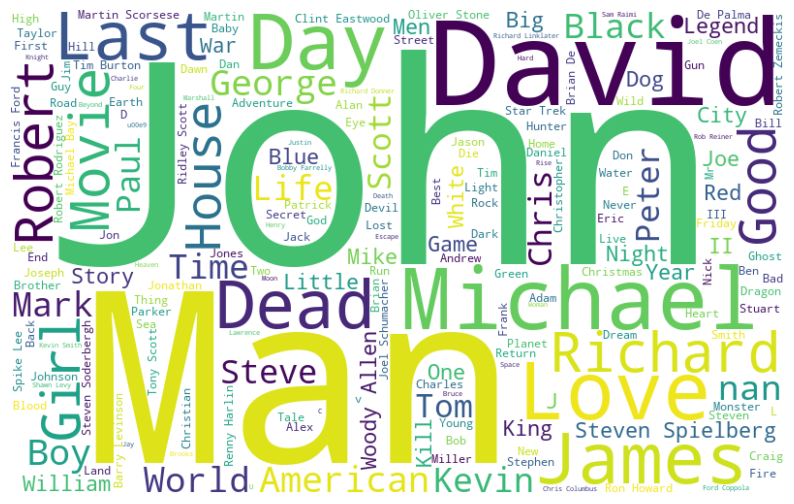

In [117]:
#once the wordcloud  is generated we show it means vusialize it to show the main data(most common words)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [118]:
# download nltk data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mahin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [142]:
#we use the unique words for the data
stop_words = set(stopwords.words('english'))

In [143]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords convert to the small chunk of data
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [144]:
# Apply preprocessing to the movie content
df['cleaned_text'] = df['title_director'].astype(str).apply(preprocess_text)

In [145]:
df.head(2)

,id,release_date,revenue,title,director,title_director,cleaned_text
0,19995,2009-12-10,2787965087,Avatar,James Cameron,Avatar James Cameron,avatar james cameron
1,285,2007-05-19,961000000,Pirates of the Caribbean: At World's End,Gore Verbinski,Pirates of the Caribbean: At World's End Gore ...,pirates caribbean worlds end gore verbinski


In [146]:
#convert each of the row in to vectors means it is going to determine the top5000 words TF - Term frequency IDF-inverse document frequency(means the repeated word is less importent) each row in this matric is a vector
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [147]:
#compute the cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(cosine_sim.shape)
print(cosine_sim[0])

(4803, 4803)
[1. 0. 0. ... 0. 0. 0.]


In [148]:
#recommendation function to get the simalarity of movie
def recommend_movies(movie_name, cosine_sim=cosine_sim, df=df, top_n=5):
    # Find the index of the movie
    idx = df[df['title'].str.lower() == movie_name.lower()].index
    if len(idx) == 0:
        return "Movie not found in the dataset!"
    idx = idx[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return top n similar movies
    return df[['title']].iloc[movie_indices]

In [149]:
df["title"]

0                                         Avatar
1       Pirates of the Caribbean: At World's End
2                                        Spectre
3                          The Dark Knight Rises
4                                    John Carter
                          ...                   
4798                                 El Mariachi
4799                                   Newlyweds
4800                   Signed, Sealed, Delivered
4801                            Shanghai Calling
4802                           My Date with Drew
Name: title, Length: 4803, dtype: object

In [157]:
#get the index naumber with providing movie name
row_index = df[df['title'] == "Pirates of the Caribbean: At World's End"].index
print(row_index)
#get the name of movie by providing the index number
movie_name = df["title"][5]
print(movie_name)

Index([1], dtype='int64')
Spider-Man 3


In [158]:
# Example Recommendation
print(f"Recommendations for the Movie {movie_name}")
recommendations = recommend_movies(movie_name)
print(recommendations)

Recommendations for the Movie Spider-Man 3
                       title
30              Spider-Man 2
159               Spider-Man
1514  The Quick and the Dead
964     For Love of the Game
4595           The Evil Dead
